# Mesh generation for FEM

The aim of this notebook is to implement the FEM for solving the 2D Poisson problem **without using the FEniCS library**. 

The first step to be taken into account for the construction of a FE solver is the **mesh generation**. 

### What is a mesh?

It is a subdivision of the spacial domain $\Omega$ into $M$ disjoint polygons (in FEM usually triangles or quadrangles). From the practical viewpoint it is just a collection of $N$ vertices belonging to $\overline{\Omega}$ together with a "graph" structure that tells which nodes are connected to form the elements.

Thus the information needed to define a mesh can be stored into two matrices: 

*   $P$ of size $N\times 2$, collecting the coordinates of the nodes;
*   $E$ of size $M\times 3$ (simplicial mesh) or $M\times 4$ (cartesian mesh), providing, for each element, which nodes belongs to its boundary.



### Cartesian mesh

In what follows we build a uniform Cartesian grid of the rectangle domain $\Omega = [0,a]\times[0,b]$, where $a$ and $b$ are scalar parameters.

In [0]:
import numpy as np
import matplotlib.pyplot as plt

In [0]:
def cartesian_mesh(a, b, nx, ny):
  '''
  construct a uniform cartesian grid of the domain [0,a] x [0,b] 
  composed of nx cells in the x-direction and ny cells in the y-direction
  '''
  P = np.zeros(((nx+1)*(ny+1),2))
  E = np.zeros((nx*ny,4), dtype=np.int)

  x = np.linspace(0, a, nx+1)
  y = np.linspace(0, b, ny+1)

  for i in range(0, nx+1):
      for j in range(0, ny+1):
          # create node matrix P (ordered from bottom-left to top-right)
          P[i*(ny+1)+j,0] = x[i]
          P[i*(ny+1)+j,1] = y[j]

          # create correspondence matrix E with local backward orientation
          if (i<nx) & (j<ny):
              E[i*ny+j,0] = i*(ny+1) + j
              E[i*ny+j,1] = (i+1)*(ny+1) + j
              E[i*ny+j,2] = (i+1)*(ny+1) + j+1
              E[i*ny+j,3] = i*(ny+1) + j+1

  return P, E

In [5]:
P, E = cartesian_mesh(1,1,2,2)
print(P)
print()
print(E)

[[0.  0. ]
 [0.  0.5]
 [0.  1. ]
 [0.5 0. ]
 [0.5 0.5]
 [0.5 1. ]
 [1.  0. ]
 [1.  0.5]
 [1.  1. ]]

[[0 3 4 1]
 [1 4 5 2]
 [3 6 7 4]
 [4 7 8 5]]


### Baricentric subdivision

One easy way to obtain a triangular mesh from a cartesian grid, consists in drawing, for each element, the two diagonals. This procedure, yielding the so called "crossed" mesh, is performed by adding one node per element (the baricentre) to $P$, then replacing each element in $E$ by the four triangle generated by connecting two of its vertices to the centre. 

This procedure (called pyramidal subdivision in 3D) can be generalized to any polygonal or polyhedral element.

In [0]:
def barycentric_subdivision(P, E, c = np.arange(0)):
  '''
  perform the barycentric subdivision of the elements in E indexed by vector c, 
  modify P accordingly, and creates a new correspondence matrix T
  '''
  n_nodes = P[:,0].size
  n_elems = E[:,0].size
  n_edges = E[0,:].size
  # if the input mesh isn't simplicial, the subdivision is done on every element
  if (n_edges > 3) or (c.size == 0):
    c = np.arange(0, n_elems)

  P_new = np.zeros((n_nodes + c.size,2))
  P_new[0:n_nodes, :] = P
  T = np.zeros((n_elems + (n_edges-1)*c.size, 3), dtype=np.int)
  T[0:n_elems,:] = E[0:n_elems,0:3]

  for i in range(0, c.size):
    # compute barycenter of the c[i] element in E and add it to P_new
    P_new[i+n_nodes,0] = sum(P[E[c[i],:],0])/n_edges
    P_new[i+n_nodes,1] = sum(P[E[c[i],:],1])/n_edges

    # create the new correspondence matrix T (with local backward orientation)
    T[c[i],0] = E[c[i],n_edges-1]
    T[c[i],1] = E[c[i],0]
    T[c[i],2] = i+n_nodes
    for j in range(0,n_edges-1):
      T[n_elems + (n_edges-1)*i + j, 0] = E[c[i],j]
      T[n_elems + (n_edges-1)*i + j, 1] = E[c[i],j+1]
      T[n_elems + (n_edges-1)*i + j, 2] = i+n_nodes

  return P_new, T

In [7]:
P, E = cartesian_mesh(1,1,2,2)
P, T = barycentric_subdivision(P, E)
print(P)
print()
print(E)
print()
print(T)

[[0.   0.  ]
 [0.   0.5 ]
 [0.   1.  ]
 [0.5  0.  ]
 [0.5  0.5 ]
 [0.5  1.  ]
 [1.   0.  ]
 [1.   0.5 ]
 [1.   1.  ]
 [0.25 0.25]
 [0.25 0.75]
 [0.75 0.25]
 [0.75 0.75]]

[[0 3 4 1]
 [1 4 5 2]
 [3 6 7 4]
 [4 7 8 5]]

[[ 1  0  9]
 [ 2  1 10]
 [ 4  3 11]
 [ 5  4 12]
 [ 0  3  9]
 [ 3  4  9]
 [ 4  1  9]
 [ 1  4 10]
 [ 4  5 10]
 [ 5  2 10]
 [ 3  6 11]
 [ 6  7 11]
 [ 7  4 11]
 [ 4  7 12]
 [ 7  8 12]
 [ 8  5 12]]


### Triangular meshes 

As observed above, the "crossed" type triangular mesh, can be derived by applying the baricentric subdivision procedure to a Cartesian grid.

Additionally, inspired by the construction of the cartesian grid, we can also define the "right" and "left" types of triangular mesh. 

In [0]:
def crossed_mesh(a, b, nx, ny):
  '''
  construct a crossed-type uniform triangular mesh of [0,a]x[0,b] starting from a 
  cartesian grid with nx cells in the x-direction and ny cells in the y-direction
  '''
  P, E = cartesian_mesh(a, b, nx, ny)
  P, T = barycentric_subdivision(P, E)

  return P, T

In [0]:
def right_mesh(a, b, nx, ny):
  '''
  construct a right-type uniform triangular mesh of [0,a] x [0,b] starting from a 
  cartesian grid with nx cells in the x-direction and ny cells in the y-direction
  '''
  P = np.zeros(((nx+1)*(ny+1),2))
  T = np.zeros((2*nx*ny,3), dtype=np.int)

  x = np.linspace(0, a, nx+1)
  y = np.linspace(0, b, ny+1)

  for i in range(0, nx+1):
      for j in range(0, ny+1):
          # create node matrix P (ordered from bottom-left to top-right)
          P[i*(ny+1)+j,0] = x[i]
          P[i*(ny+1)+j,1] = y[j]

          # create correspondence matrix T with local backward orientation
          if (i<nx) & (j<ny):
              T[2*(i*ny+j),0] = i*(ny+1) + j
              T[2*(i*ny+j),1] = (i+1)*(ny+1) + j
              T[2*(i*ny+j),2] = (i+1)*(ny+1) + j+1
              
              T[2*(i*ny+j)+1,0] = (i+1)*(ny+1) + j+1
              T[2*(i*ny+j)+1,1] = i*(ny+1) + j+1
              T[2*(i*ny+j)+1,2] = i*(ny+1) + j

  return P, T

In [0]:
def left_mesh(a, b, nx, ny):
  '''
  construct a left-type uniform triangular mesh of [0,a] x [0,b] starting from a 
  cartesian grid with nx cells in the x-direction and ny cells in the y-direction
  '''
  P = np.zeros(((nx+1)*(ny+1),2))
  T = np.zeros((2*nx*ny,3), dtype=np.int)

  x = np.linspace(0, a, nx+1)
  y = np.linspace(0, b, ny+1)

  for i in range(0, nx+1):
      for j in range(0, ny+1):
          # create node matrix P (ordered from bottom-left to top-right)
          P[i*(ny+1)+j,0] = x[i]
          P[i*(ny+1)+j,1] = y[j]

          # create correspondence matrix T with local backward orientation
          if (i<nx) & (j<ny):
              T[2*(i*ny+j),0] = i*(ny+1) + j
              T[2*(i*ny+j),1] = (i+1)*(ny+1) + j
              T[2*(i*ny+j),2] = i*(ny+1) + j+1
              
              T[2*(i*ny+j)+1,0] = i*(ny+1) + j+1
              T[2*(i*ny+j)+1,1] = (i+1)*(ny+1) + j
              T[2*(i*ny+j)+1,2] = (i+1)*(ny+1) + j+1

  return P, T

### Some examples

Before assessing some possible applications of the previous meshing algorithms, we define a simple plot function.  

In [0]:
def plot_mesh(P, E):
  for i in range(E[:,0].size):
    x = [P[E[i, E[0,:].size-1], 0], P[E[i, 0], 0]]
    y = [P[E[i, E[0,:].size-1], 1], P[E[i, 0], 1]]
    plt.plot(x, y, "k")
    for j in range(E[0,:].size-1):
      x = [P[E[i, j], 0], P[E[i, j+1], 0]]
      y = [P[E[i, j], 1], P[E[i, j+1], 1]]
      plt.plot(x, y, "k")
        
  plt.show()

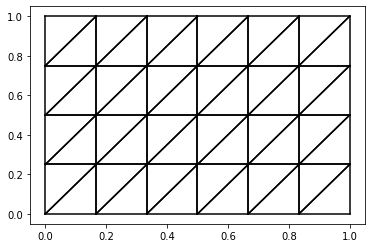

In [12]:
P, T = right_mesh(1,1,6,4)
plot_mesh(P, T)

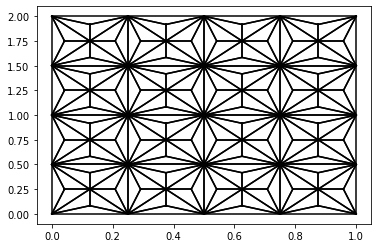

In [13]:
P, T = crossed_mesh(1,2,4,4)
P, T = barycentric_subdivision(P, T)
plot_mesh(P, T)

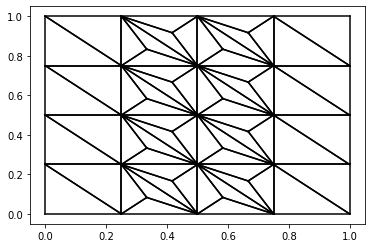

In [14]:
P, T = left_mesh(1,1,4,4)
c = np.arange(8,24)
P, T = barycentric_subdivision(P, T, c)
plot_mesh(P, T)

Using the baricentric subdivision we can mesh domain with more complex shapes. However, as we can notice above, iterating the procedure leads to undesired streched elements.

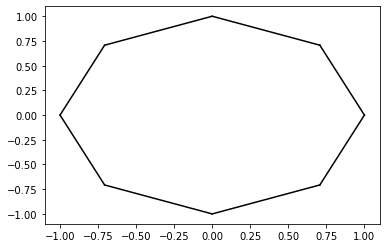

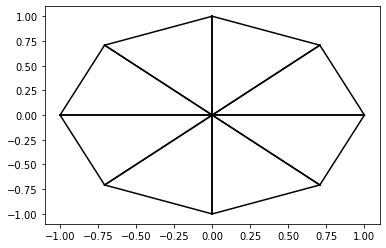

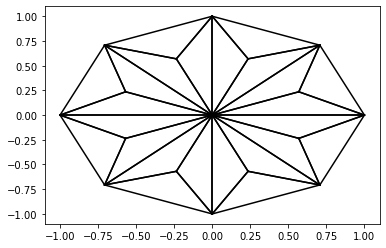

In [15]:
P = np.zeros((8,2))
for i in range(0,8):
  P[i,0] = np.cos(i*np.pi/4.)
  P[i,1] = np.sin(i*np.pi/4.)

E = np.zeros((1,8), dtype=int)
E[0,:] = range(8)
plot_mesh(P, E)

P, T = barycentric_subdivision(P, E)
plot_mesh(P, T)

P, T = barycentric_subdivision(P, T)
plot_mesh(P, T)

#### **Exercise**: In order to avoid streched elements, other refining procedure can be adopted. One possibility is, for instance, to add to P the midpoints of a subset of the edges composing the mesh skeleton. Then, for each of these edges, add to E the elements generating from joining the midpoint with the opposed vertices of the neighbouring elements. Define the function *midpoint_subdivision* implementing this procedure.     

In [0]:
def midpoint_subdivision(P, T, n_bndry):
  '''
  perform the midpoint subdivision of ALL the elements in T, 
  modify P accordingly, and creates a new correspondence matrix T
  '''
  n_nodes = P[:,0].size
  n_elems = T[:,0].size
  n_edges = 3*n_elems
  #n_edges = 2*n_elems + 1 + n_bndry - n_nodes

  P_new = np.zeros((n_nodes + n_edges,2))
  P_new[0:n_nodes, :] = P
  T_new = np.zeros((4*n_elems, 3), dtype=np.int)

  for i in range(n_elems):
    # compute midpoints of the edges in the i-th element in T and add it to P_new
    P_new[3*i+n_nodes,0] = (P[T[i,0],0] + P[T[i,1],0])/2
    P_new[3*i+n_nodes,1] = (P[T[i,0],1] + P[T[i,1],1])/2

    P_new[3*i+1+n_nodes,0] = (P[T[i,1],0] + P[T[i,2],0])/2
    P_new[3*i+1+n_nodes,1] = (P[T[i,1],1] + P[T[i,2],1])/2

    P_new[3*i+2+n_nodes,0] = (P[T[i,2],0] + P[T[i,0],0])/2
    P_new[3*i+2+n_nodes,1] = (P[T[i,2],1] + P[T[i,0],1])/2

    # create the new correspondence matrix T (with local backward orientation)
    T_new[4*i,0] = 3*i+n_nodes
    T_new[4*i,1] = 3*i+1+n_nodes
    T_new[4*i,2] = 3*i+2+n_nodes
    T_new[4*i+1,0] = T[i,0]
    T_new[4*i+1,1] = 3*i+n_nodes
    T_new[4*i+1,2] = 3*i+2+n_nodes
    T_new[4*i+2,0] = T[i,1]
    T_new[4*i+2,1] = 3*i+1+n_nodes
    T_new[4*i+2,2] = 3*i+n_nodes
    T_new[4*i+3,0] = T[i,2]
    T_new[4*i+3,1] = 3*i+2+n_nodes
    T_new[4*i+3,2] = 3*i+1+n_nodes

  return P_new, T_new

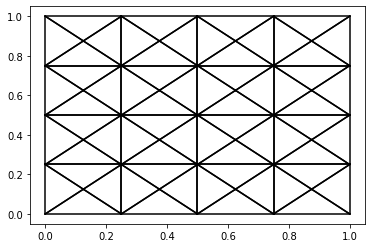

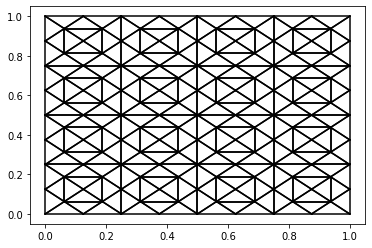

In [27]:
P, T = crossed_mesh(1,1,4,4)
plot_mesh(P,T)
P, T = midpoint_subdivision(P, T, 16)
plot_mesh(P,T)

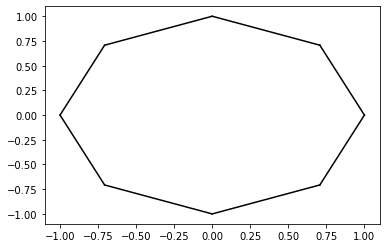

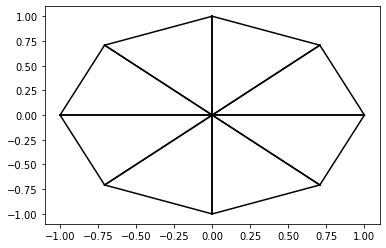

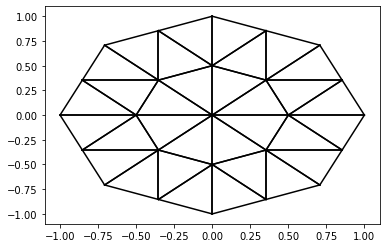

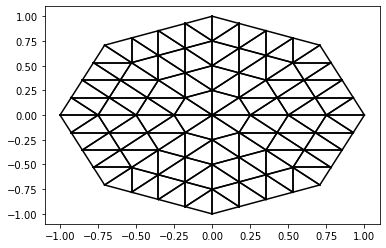

In [30]:
P = np.zeros((8,2))
for i in range(0,8):
  P[i,0] = np.cos(i*np.pi/4.)
  P[i,1] = np.sin(i*np.pi/4.)

E = np.zeros((1,8), dtype=int)
E[0,:] = range(8)
plot_mesh(P, E)

P, T = barycentric_subdivision(P, E)
plot_mesh(P, T)

P, T = midpoint_subdivision(P, T, 8)
plot_mesh(P, T)

P, T = midpoint_subdivision(P, T, 16)
plot_mesh(P, T)